# Simulación de una línea de espera de un sólo servidor
## Solución Analítica


Simulamos una cola de $M/M/1$, donde para las entradas y salidas de nuestros clientes con un śolo servidor o cajero, son un proceso de Poisson. Tendremos que con $\lambda=4$ y $\mu=6$. SIendo que cada uno respresenta el tiempo de razón de llegada y el otro la razón del servicio.


Veremos que de las fórmulas para este caso, tendremos que para nuestra línea de espera, su factor de utilización es:

$$
\rho=\frac{\lambda}{\mu}=\frac{4}{6}=\frac{2}{3}\approx 66.6\% \text{ utilización.}
$$

Buscamos comprobar con la simulación que el tiempo promedio de espera de la línea de espera sea
$$
W_q=\frac{\lambda}{\mu(\mu-\lambda)}=\frac{4}{12}=\frac{1}{3}\approx 0.33 \text{ hora.}
$$

In [16]:
#Librerías a utilizar
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [10]:
# ============================================================
# Parámetros
# ============================================================
lam = 4.0      # tasa llegadas
mu = 6.0       # tasa servicio
maxT = 200.0   # tiempo de simulación por réplica (para alcanzar estado estable)
n_replicas = 500

# ============================================================
# Teoría M/M/1
# ============================================================
rho = lam / mu
L_teo = rho / (1 - rho)            # número medio en sistema
W_teo = L_teo / lam                # tiempo medio en sistema
Wq_teo = W_teo - 1/mu              # tiempo medio en cola
Lq_teo = lam * Wq_teo              # número medio en cola

print("=== VALORES TEÓRICOS ===")
print(f"ρ = {rho:.4f}")
print(f"L (número medio en sistema) = {L_teo:.4f}")
print(f"W (tiempo medio en sistema) = {W_teo:.4f}")
print(f"Wq (tiempo medio en cola)   = {Wq_teo:.4f}")
print(f"Lq (número medio en cola)   = {Lq_teo:.4f}\n")


=== VALORES TEÓRICOS ===
ρ = 0.6667
L (número medio en sistema) = 2.0000
W (tiempo medio en sistema) = 0.5000
Wq (tiempo medio en cola)   = 0.3333
Lq (número medio en cola)   = 1.3333



## Simulación

In [12]:
# ============================================================
# Simulación de una réplica (M/M/1)
# ============================================================
def simular_mm1(lam, mu, maxT):
    """
    Retorna:
        tiempos_espera_cola (lista), tiempos_sistema (lista),
        tiempos_evento, num_clientes_evento (para graficar evolución)
    """
    clock = 0.0
    n = 0
    t_arv = -np.log(np.random.rand()) / lam
    t_dep = np.inf
    
    arrival_times = []
    service_start_times = []
    departure_times = []
    
    event_times = [0.0]
    event_n = [0]
    
    while clock < maxT:
        if t_arv <= t_dep and t_arv <= maxT:
            # Llegada
            # Acumular tiempo en estado actual (para métricas de ocupación, opcional)
            # Llegada del cliente
            arrival_times.append(t_arv)
            clock = t_arv
            n += 1
            # Próxima llegada
            t_arv = clock + (-np.log(np.random.rand()) / lam)
            
            if n == 1:
                # El sistema estaba vacío, este cliente entra al servicio inmediatamente
                serv_time = -np.log(np.random.rand()) / mu
                t_dep = clock + serv_time
                service_start_times.append(clock)  # inicio de servicio = llegada
            # Si n>1, el cliente se encola; su inicio de servicio se asignará cuando salga el anterior
            
            event_times.append(clock)
            event_n.append(n)
        
        else:
            # Salida (t_dep < t_arv o t_dep <= maxT)
            clock = t_dep
            departure_times.append(clock)
            n -= 1
            
            if n > 0:
                # El siguiente cliente en cola comienza servicio ahora
                # El cliente que comienza es el que llegó más temprano entre los que esperan.
                # Para saber su tiempo de inicio, lo registramos.
                # Como no tenemos una cola explícita, podemos usar el hecho de que el orden de llegada es el mismo que el orden de salida,
                # y el número de inicios de servicio registrados hasta ahora es igual al número de clientes que ya han salido.
                # El cliente que empieza ahora es el (len(service_start_times))-ésimo en llegar (0-indexado).
                # Su tiempo de inicio es el clock actual.
                service_start_times.append(clock)
                serv_time = -np.log(np.random.rand()) / mu
                t_dep = clock + serv_time
            else:
                t_dep = np.inf
            
            event_times.append(clock)
            event_n.append(n)
    
    # Procesar clientes remanentes después de maxT (si los hay)
    while n > 0 and t_dep < np.inf:
        clock = t_dep
        departure_times.append(clock)
        n -= 1
        if n > 0:
            service_start_times.append(clock)
            serv_time = -np.log(np.random.rand()) / mu
            t_dep = clock + serv_time
        else:
            t_dep = np.inf
        event_times.append(clock)
        event_n.append(n)
    
    # Calcular tiempos de espera en cola y sistema
    n_clientes = min(len(departure_times),len(arrival_times),len(service_start_times))
    waiting_times = []
    system_times = []
    for i in range(n_clientes):
        # El i-ésimo cliente en salir es el i-ésimo en llegar (FIFO)
        arr = arrival_times[i]
        dep = departure_times[i]
        # El inicio de servicio del i-ésimo cliente debería ser service_start_times[i]
        
        start_service = service_start_times[i]
        waiting_times.append(start_service - arr)
        system_times.append(dep - arr)
    
    return waiting_times, system_times, event_times, event_n

In [13]:
# ============================================================
# Múltiples réplicas para obtener IC
# ============================================================
all_waiting = []   # lista de todos los tiempos de espera (todas las réplicas)
all_system = []    # lista de todos los tiempos en sistema

for rep in range(n_replicas):
    wq, ws, _, _ = simular_mm1(lam, mu, maxT)
    all_waiting.extend(wq)
    all_system.extend(ws)

# Estadísticas globales
Wq_sim = np.mean(all_waiting)
W_sim = np.mean(all_system)
L_sim = W_sim * lam          # por Little
Lq_sim = Wq_sim * lam

# Intervalos de confianza (95%) usando percentiles (o normal)
ic_wq = np.percentile(all_waiting, [2.5, 97.5])
ic_ws = np.percentile(all_system, [2.5, 97.5])

print("=== RESULTADOS SIMULADOS ===")
print(f"Wq simulado = {Wq_sim:.4f}  (IC95%: {ic_wq[0]:.4f}, {ic_wq[1]:.4f})")
print(f"W  simulado = {W_sim:.4f}  (IC95%: {ic_ws[0]:.4f}, {ic_ws[1]:.4f})")
print(f"Lq simulado = {Lq_sim:.4f}")
print(f"L  simulado = {L_sim:.4f}")

=== RESULTADOS SIMULADOS ===
Wq simulado = 0.3312  (IC95%: 0.0000, 1.6341)
W  simulado = 0.4974  (IC95%: 0.0125, 1.8366)
Lq simulado = 1.3248
L  simulado = 1.9894


In [14]:
# Comparación con valores teóricos
error_wq = abs(Wq_sim - Wq_teo)
print(f"\nDiferencia |Wq_sim - Wq_teo| = {error_wq:.6f}")



Diferencia |Wq_sim - Wq_teo| = 0.002139


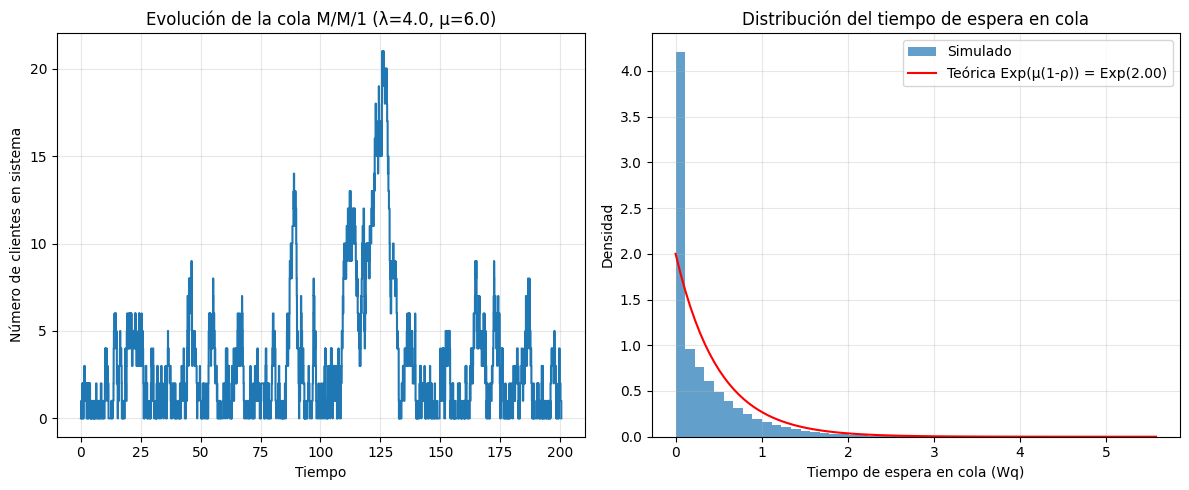

In [15]:
# ============================================================
# Gráficas: evolución de la cola y distribución de tiempos
# ============================================================
# Ejecutar una réplica para graficar la evolución
_, _, t_ev, n_ev = simular_mm1(lam, mu, maxT)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.step(t_ev, n_ev, where='post')
plt.xlabel('Tiempo')
plt.ylabel('Número de clientes en sistema')
plt.title(f'Evolución de la cola M/M/1 (λ={lam}, μ={mu})')
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.hist(all_waiting, bins=50, density=True, alpha=0.7, label='Simulado')
# Añadir densidad teórica exponencial para Wq? Para M/M/1, Wq tiene distribución exponencial con tasa μ(1-ρ)
x = np.linspace(0, max(all_waiting), 100)
y = (mu*(1-rho)) * np.exp(-mu*(1-rho)*x)
plt.plot(x, y, 'r-', label=f'Teórica Exp(μ(1-ρ)) = Exp({mu*(1-rho):.2f})')
plt.xlabel('Tiempo de espera en cola (Wq)')
plt.ylabel('Densidad')
plt.title('Distribución del tiempo de espera en cola')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()